# **Image Inpainting: Classical vs. LaMa (DNN)**

## **Objectives:**
1. Remove an object from a photo with classical, PDE-based inpainting (`cv2.inpaint`)
2. Remove the same object with **LaMa**, a deep generative inpainting model built into OpenCV 5 itself
3. See exactly *where* and *why* texture defeats the classical method, and why a learned model doesn't have that problem

> **⚠ Different environment than every other notebook in this repo.** This one needs `opencv-contrib-python-headless==5.0.0.93`, not the `opencv-python-headless==4.10.0.84` every other notebook here is pinned to — confirmed empirically, not just from documentation: LaMa's ONNX graph uses a `DequantizeLinear` op that 4.x's DNN importer flatly cannot parse (`handleNode` error), one concrete instance of the ~22% → ~80% ONNX op coverage jump OpenCV 5 shipped. Run `.venv5x/bin/jupyter notebook` (after `pip install -r requirements-5x.txt` — see the README's "OpenCV 5.x notebooks" section) and select the **Python 3 (OpenCV 5.x)** kernel, not the repo's usual one.

> **Assets.** `assets/models/inpainting_lama_2025jan.onnx` is LaMa ("Large Mask inpainting"), redistributed by OpenCV's own model zoo on Hugging Face ([opencv/inpainting_lama](https://huggingface.co/opencv/inpainting_lama), Apache 2.0 — originally from [advimman/lama](https://github.com/advimman/lama)). **This file is ~92MB — by far the single largest asset in this repo** (the next largest is an 8MB video). No smaller quantized export was available from OpenCV's own distribution at the time of writing; worth knowing before cloning on a slow connection.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Why a straight line through a photo isn't a straight line to fix**

Classical inpainting (`cv2.inpaint`, notebook-new here but a long-standing OpenCV function) works by solving a partial differential equation that propagates color and gradient information inward from the mask's boundary — think of it as carefully diffusing the surrounding pixels into the gap, guided by the edges that reach the boundary. This works remarkably well for *smooth, low-frequency* regions — a scratch across a clear sky, a watermark on a plain background. It has no way to *understand* what it's filling in, though: for anything with real texture or structure inside the masked region, the best it can do is blur nearby pixels together.

**LaMa** is a fully generative model — trained on millions of photos with masks, it learned an actual prior over what "the rest of a photo" plausibly looks like, using large receptive-field convolutions specifically so it can reason about masks far bigger than the classical method could ever handle sensibly. It's not propagating pixels from the boundary; it's synthesizing new, plausible content.

## **Removing the ball from `messi5.jpg`**

Reusing the exact bounding box notebook 33's YOLOX detector found for the "sports ball" — a real object, a real detected region, not a hand-picked mask. The background behind it is grass: real texture, a real edge (the penalty-area line) — exactly the case classical inpainting struggles with.

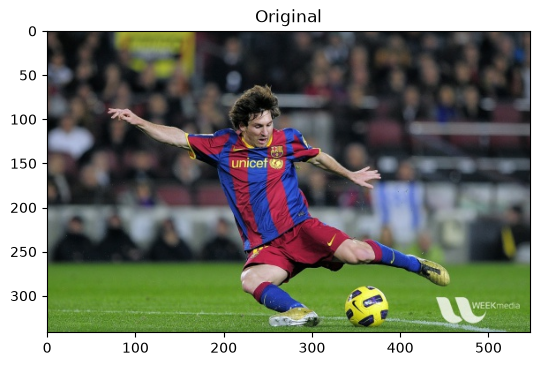

In [2]:
image = cv2.imread('assets/images/messi5.jpg')
h, w = image.shape[:2]
imshow('Original', image)

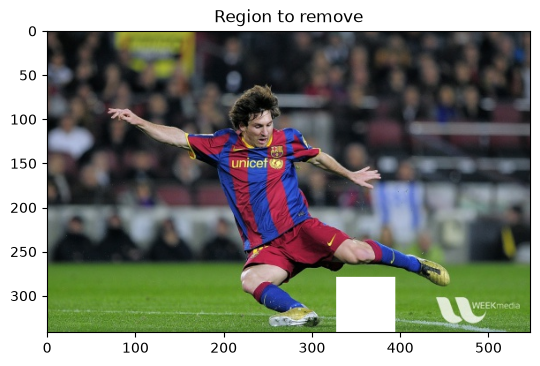

In [3]:
# The ball's box from notebook 33's YOLOX detection: (336, 287, 50, 49)
x, y, bw, bh = 336, 287, 50, 49
pad = 8
mask = np.zeros((h, w), dtype=np.uint8)
cv2.rectangle(mask, (x - pad, y - pad), (x + bw + pad, y + bh + pad), 255, -1)

masked_preview = image.copy()
masked_preview[mask > 0] = (255, 255, 255)
imshow('Region to remove', masked_preview)

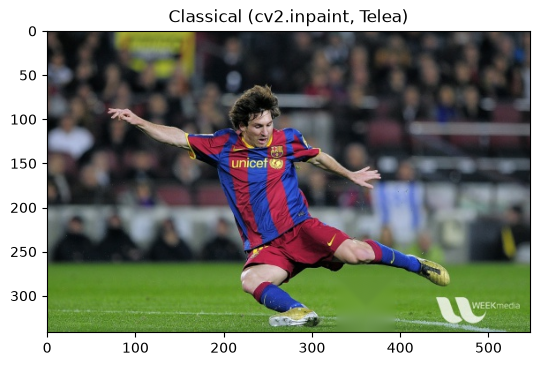

In [4]:
classical = cv2.inpaint(image, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)
imshow('Classical (cv2.inpaint, Telea)', classical)

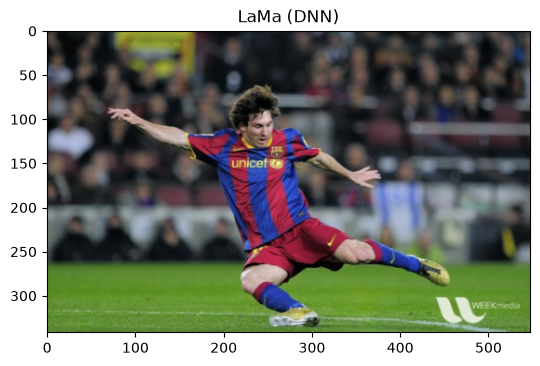

In [5]:
lama_net = cv2.dnn.readNetFromONNX('assets/models/inpainting_lama_2025jan.onnx')

def lama_inpaint(net, img, mask):
    # Fixed 512x512 input, two named inputs — this is LaMa's own contract,
    # not a general cv2.dnn convention.
    image_blob = cv2.dnn.blobFromImage(img, 1 / 255.0, (512, 512), (0, 0, 0), swapRB=False, crop=False)
    mask_blob = cv2.dnn.blobFromImage(mask, 1.0, (512, 512), (0,), swapRB=False, crop=False)
    mask_blob = (mask_blob > 0).astype(np.float32)

    net.setInput(image_blob, 'image')
    net.setInput(mask_blob, 'mask')
    out = net.forward()

    result = np.transpose(out[0], (1, 2, 0)).astype(np.uint8)
    return cv2.resize(result, (img.shape[1], img.shape[0]))

lama_result = lama_inpaint(lama_net, image, mask)
imshow('LaMa (DNN)', lama_result)

## **Zooming in on exactly what changed**

The full-image view above already looks decent for both — the real difference is only obvious up close, at the boundary between the smooth part of the lawn and the penalty-area line running through the masked region.

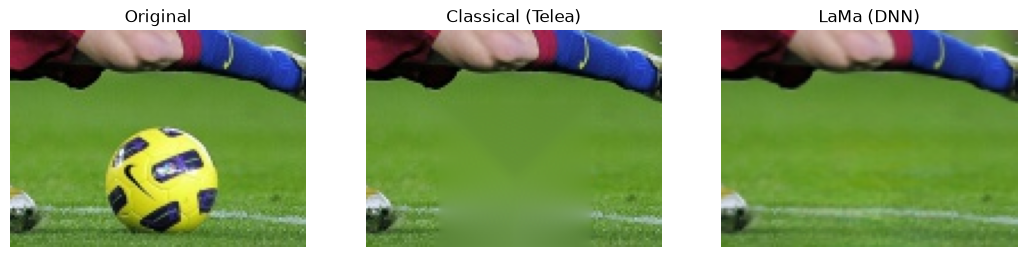

Classical inpainting blurs the boundary line into a smudge — it has no concept of "there is a straight white line here", only nearby colors to diffuse inward. LaMa continues the line and the grass texture as if it was never interrupted, because it learned what grass-with-a-line-through-it actually looks like, not just how to blend colors.


In [6]:
zoom_pad = 40
x0, y0 = x - zoom_pad, y - zoom_pad
x1, y1 = x + bw + zoom_pad, y + bh + zoom_pad

crops = [image[y0:y1, x0:x1], classical[y0:y1, x0:x1], lama_result[y0:y1, x0:x1]]
titles = ['Original', 'Classical (Telea)', 'LaMa (DNN)']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, crop, title in zip(axes, crops, titles):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.show()

print('Classical inpainting blurs the boundary line into a smudge — it has no '
      'concept of "there is a straight white line here", only nearby colors to '
      'diffuse inward. LaMa continues the line and the grass texture as if it '
      'was never interrupted, because it learned what grass-with-a-line-through-it '
      'actually looks like, not just how to blend colors.')

### If you're curious to dig deeper

- Mask something *without* a straight edge running through it (a patch of plain sky in `assets/images/home.jpg`) — classical inpainting should hold up far better there, which is the honest boundary of where it's actually fine.
- Make the mask deliberately huge (half the image) — LaMa was specifically designed with a large receptive field for exactly this case; classical inpainting falls apart much sooner.
- Try `cv2.INPAINT_NS` (Navier-Stokes) instead of `INPAINT_TELEA` for the classical baseline — a different PDE, similar class of limitation.